# UPI won. So why is India holding more cash than ever?

In 2025-26 Indians made **242 billion UPI payments** worth ₹314 lakh crore. Over the same year,
the cash in circulation grew **11.8% to a record ₹41.7 lakh crore**, its fastest growth since COVID.
If UPI is replacing cash, why does India keep printing more of it?

**Short answer:**
1. **Relative to the economy, cash hasn't grown or shrunk.** It's **12.0% of GDP**, exactly where it was in
   2014-15, before UPI existed. Apart from two shocks (demonetisation and COVID), it has stayed between
   11.7% and 12.8% of GDP for 16 years. Cash rises because the economy does.
2. **UPI replaced cash as a way to *pay*, not as a way to *hold* money.** UPI's yearly value grew from 37% to
   91% of GDP in four years, and the average UPI payment fell from ₹1,831 to ₹1,301. That's small,
   everyday spending that used to be cash. Debit-card payments at shops fell 67%.
3. **Cash behaves like savings.** It jumped when the economy shrank (COVID), and it builds up every
   October–May and drains every June–September.

Data: RBI Handbook of Statistics (Tables 1, 36, 58, 165), World Bank. All modelling is in SQL (DuckDB):
see `sql/`. Run `python src/parse_sources.py && python src/run_sql.py` first.

In [1]:
import sys
import warnings
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore", category=UserWarning)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from style import AQUA, BLUE, BLUE_LIGHT, INK, INK_2, MAGENTA, NEUTRAL, ORANGE, VIOLET, footnote, save, titles  # noqa: E402

con = duckdb.connect(str(ROOT / "data" / "upi_cash.duckdb"), read_only=True)
sql = lambda q: con.sql(q).df()
pd.set_option("display.precision", 2)

## 1. Data-quality checks

The pipeline won't publish if any check fails. One check compares two RBI tables against each other: the
March value in the monthly series must equal the annual (end-March) figure.

In [2]:
sql("SELECT check_name, detail, passed FROM dq_results ORDER BY check_name, detail")

,check_name,detail,passed
0,cash: monthly March = annual table,2022-23,True
1,cash: monthly March = annual table,2023-24,True
2,cash: monthly March = annual table,2024-25,True
3,cash: monthly March = annual table,2025-26,True
4,cash: monthly series has no gaps,2022-04-01 to 2026-05-01,True
5,gdp: World Bank matches RBI,2020-21,True
6,gdp: World Bank matches RBI,2021-22,True
7,gdp: base-year splice factor between 0.9 and 1.1,0.9713,True
8,gdp: one value per year 2010-11 to 2025-26,16 years,True
9,marts: no negative or missing headline values,"cash, gdp, upi",True


## 2. The paradox in one query

In [3]:
sql("""
    SELECT c.fiscal_year,
           c.cash_lakh_cr,
           c.cash_growth_pct,
           c.cash_to_gdp_pct,
           u.upi_txns_bn,
           u.upi_value_lakh_cr,
           u.upi_value_to_gdp_pct
    FROM mart_cash_annual c
    LEFT JOIN mart_upi_annual u USING (fy_start)
    WHERE c.fy_start IN (2014, 2015, 2021, 2022, 2023, 2024, 2025)
    ORDER BY c.fy_start
""")

,fiscal_year,cash_lakh_cr,cash_growth_pct,cash_to_gdp_pct,upi_txns_bn,upi_value_lakh_cr,upi_value_to_gdp_pct
0,2014-15,14.48,11.3,11.96,NaN,NaN,NaN
1,2015-16,16.63,14.9,12.44,NaN,NaN,NaN
2,2021-22,31.34,9.8,13.67,46.0,84.2,36.7
3,2022-23,33.79,7.8,12.94,83.7,139.1,53.3
4,2023-24,35.11,3.9,12.12,131.1,200.0,69.0
5,2024-25,37.24,6.1,11.71,185.9,260.6,81.9
6,2025-26,41.66,11.8,12.03,241.6,314.2,90.7


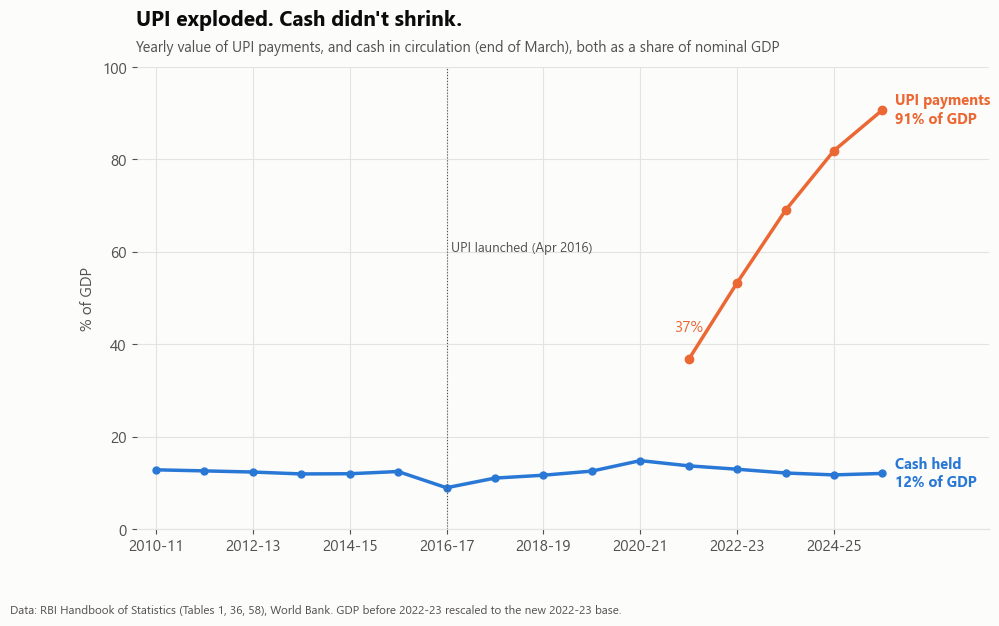

In [4]:
cash = sql("SELECT * FROM mart_cash_annual ORDER BY fy_start")
upi = sql("SELECT * FROM mart_upi_annual ORDER BY fy_start")

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(cash.fy_start, cash.cash_to_gdp_pct, color=BLUE, lw=2.5, marker="o", ms=5)
ax.plot(upi.fy_start, upi.upi_value_to_gdp_pct, color=ORANGE, lw=2.5, marker="o", ms=6)
ax.text(2025.25, cash.cash_to_gdp_pct.iloc[-1], f"Cash held\n{cash.cash_to_gdp_pct.iloc[-1]:.0f}% of GDP",
        color=BLUE, fontsize=10.5, va="center", fontweight="bold")
ax.text(2025.25, upi.upi_value_to_gdp_pct.iloc[-1], f"UPI payments\n{upi.upi_value_to_gdp_pct.iloc[-1]:.0f}% of GDP",
        color=ORANGE, fontsize=10.5, va="center", fontweight="bold")
ax.text(2021, upi.upi_value_to_gdp_pct.iloc[0] + 6, f"{upi.upi_value_to_gdp_pct.iloc[0]:.0f}%", color=ORANGE, ha="center")
ax.axvline(2016, color=INK_2, lw=0.8, ls=":")
ax.text(2016.1, 60, "UPI launched (Apr 2016)", color=INK_2, fontsize=9.5)
ax.set_xticks(cash.fy_start[::2], cash.fiscal_year[::2])
ax.set_xlim(2009.6, 2027.2)
ax.set_ylim(0, 100)
ax.set_ylabel("% of GDP")
titles(ax, "UPI exploded. Cash didn't shrink.",
       "Yearly value of UPI payments, and cash in circulation (end of March), both as a share of nominal GDP")
footnote(fig, "Data: RBI Handbook of Statistics (Tables 1, 36, 58), World Bank. GDP before 2022-23 rescaled to the new 2022-23 base.", y=-0.03)
save(fig, "01_upi_vs_cash.png")
plt.show()

## 3. Cash has stayed at about 12% of GDP for 16 years

The two exceptions are both shocks to *trust and liquidity*, not to payment habits. Demonetisation
(Nov 2016) mechanically removed 86% of notes. COVID (2020-21) made households hoard cash while GDP fell.

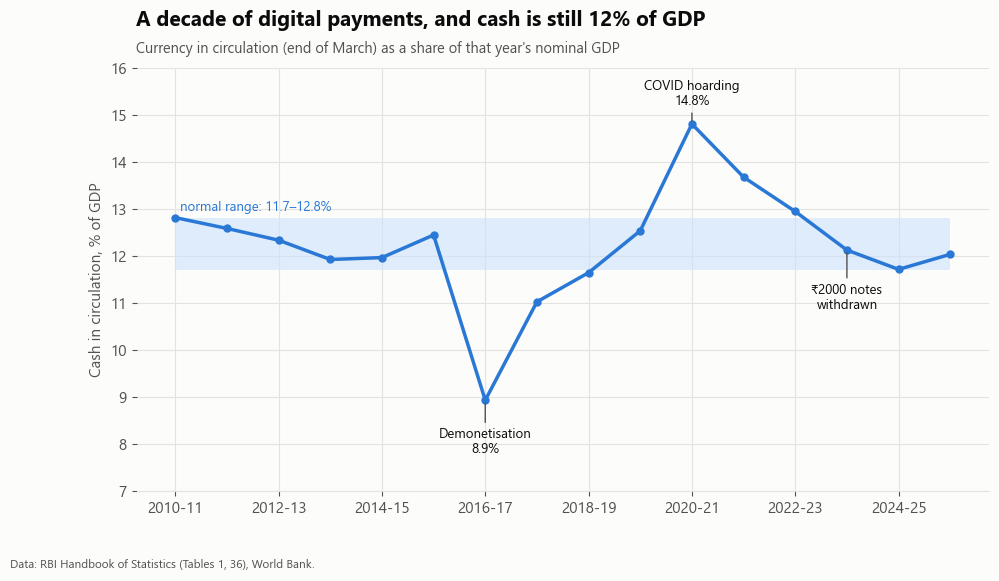

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.fill_between(cash.fy_start, 11.7, 12.8, color=BLUE_LIGHT, alpha=0.6, lw=0)
ax.text(2010.1, 12.95, "normal range: 11.7–12.8%", color=BLUE, fontsize=9.5)
ax.plot(cash.fy_start, cash.cash_to_gdp_pct, color=BLUE, lw=2.5, marker="o", ms=5)
notes = {2016: ("Demonetisation\n8.9%", (0, -38)), 2020: ("COVID hoarding\n14.8%", (0, 14)),
         2023: ("₹2000 notes\nwithdrawn", (0, -42))}
for fy, (label, offset) in notes.items():
    v = cash.set_index("fy_start").cash_to_gdp_pct[fy]
    ax.annotate(label, (fy, v), xytext=offset, textcoords="offset points", ha="center", fontsize=9.5,
                arrowprops=dict(arrowstyle="-", color=INK_2))
ax.set_xticks(cash.fy_start[::2], cash.fiscal_year[::2])
ax.set_ylim(7, 16)
ax.set_ylabel("Cash in circulation, % of GDP")
titles(ax, "A decade of digital payments, and cash is still 12% of GDP",
       "Currency in circulation (end of March) as a share of that year's nominal GDP")
footnote(fig, "Data: RBI Handbook of Statistics (Tables 1, 36), World Bank.", y=-0.03)
save(fig, "02_cash_to_gdp.png")
plt.show()

## 4. What UPI actually replaced

UPI's share of non-cash payments rose from 63% to 86% in four years. Most of that came from other
*digital* channels. Debit cards at shops collapsed, and the average UPI payment keeps getting smaller.

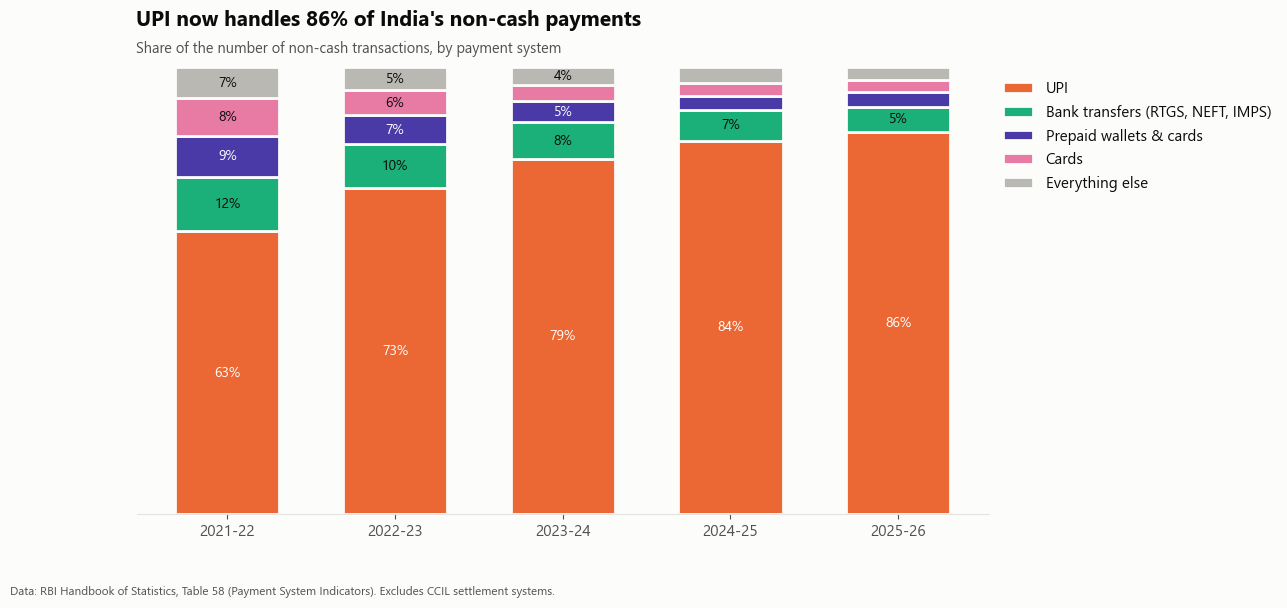

In [6]:
mix = sql("""
    SELECT fiscal_year,
           CASE WHEN category IN ('UPI', 'Bank transfers (RTGS, NEFT, IMPS)', 'Prepaid wallets & cards', 'Cards')
                THEN category ELSE 'Everything else' END AS category,
           SUM(share_of_volume_pct) AS share_pct
    FROM mart_payments
    GROUP BY ALL
    ORDER BY fiscal_year
""").pivot(index="fiscal_year", columns="category", values="share_pct")
order = ["UPI", "Bank transfers (RTGS, NEFT, IMPS)", "Prepaid wallets & cards", "Cards", "Everything else"]
colors = [ORANGE, AQUA, VIOLET, MAGENTA, NEUTRAL]

fig, ax = plt.subplots(figsize=(11, 5.8))
bottom = np.zeros(len(mix))
for cat, color in zip(order, colors):
    vals = mix[cat].values
    ax.bar(mix.index, vals, bottom=bottom, color=color, width=0.62, edgecolor="#fcfcfb", linewidth=2, label=cat)
    for x, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 4:
            ax.text(x, b + v / 2, f"{v:.0f}%", ha="center", va="center", fontsize=10,
                    color="white" if cat in ("UPI", "Prepaid wallets & cards") else INK)
    bottom += vals
ax.set_ylim(0, 100)
ax.set_yticks([])
ax.grid(False)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
titles(ax, "UPI now handles 86% of India's non-cash payments",
       "Share of the number of non-cash transactions, by payment system")
footnote(fig, "Data: RBI Handbook of Statistics, Table 58 (Payment System Indicators). Excludes CCIL settlement systems.", y=-0.03)
save(fig, "03_payment_mix.png")
plt.show()

volume_bn         avg_ticket_rupees        
system      Debit Cards     UPI       Debit Cards     UPI
fiscal_year                                              
2021-22            3.94   45.96            1854.0  1831.0
2022-23            3.42   83.71            2107.0  1662.0
2023-24            2.29  131.13            2592.0  1525.0
2024-25            1.61  185.87            3076.0  1402.0
2025-26            1.28  241.62            3480.0  1301.0

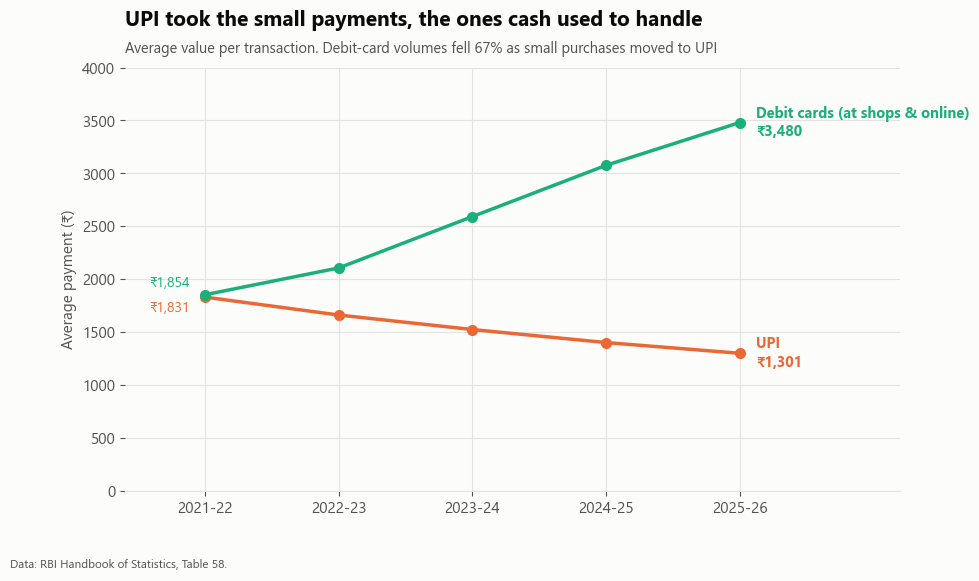

In [7]:
tickets = sql("""
    SELECT fiscal_year, system, avg_ticket_rupees, volume_bn
    FROM mart_payments
    WHERE system IN ('UPI', 'Debit Cards')
    ORDER BY fiscal_year
""")
display(tickets.pivot(index="fiscal_year", columns="system", values=["volume_bn", "avg_ticket_rupees"]))

fig, ax = plt.subplots(figsize=(10, 5.5))
for system, color, label, nudge in (("UPI", ORANGE, "UPI", -110), ("Debit Cards", AQUA, "Debit cards (at shops & online)", 110)):
    t = tickets[tickets.system == system]
    ax.plot(t.fiscal_year, t.avg_ticket_rupees, color=color, lw=2.5, marker="o", ms=7)
    ax.text(4.12, t.avg_ticket_rupees.iloc[-1], f"{label}\n₹{t.avg_ticket_rupees.iloc[-1]:,.0f}", color=color,
            fontsize=10.5, va="center", fontweight="bold")
    # the two series start almost level, so their first labels are nudged apart
    ax.text(-0.12, t.avg_ticket_rupees.iloc[0] + nudge, f"₹{t.avg_ticket_rupees.iloc[0]:,.0f}", color=color,
            fontsize=10, ha="right", va="center")
ax.set_xlim(-0.6, 5.2)
ax.set_ylim(0, 4000)
ax.set_ylabel("Average payment (₹)")
titles(ax, "UPI took the small payments, the ones cash used to handle",
       "Average value per transaction. Debit-card volumes fell 67% as small purchases moved to UPI")
footnote(fig, "Data: RBI Handbook of Statistics, Table 58.", y=-0.03)
save(fig, "04_ticket_size.png")
plt.show()

## 5. When India reaches for cash

Monthly data (April 2022 – May 2026) shows a strong seasonal rhythm. Cash builds from October (festivals,
weddings) through May (financial year-end, rabi harvest), then drains through the monsoon. The withdrawal
of ₹2000 notes in May 2023 pulled cash down sharply as notes were deposited back into banks.

In [8]:
monthly = sql("SELECT * FROM mart_cash_monthly ORDER BY month")
seasonal = sql("SELECT * FROM mart_cash_seasonality ORDER BY month_num")
seasonal

,month_num,month_name,avg_mom_pct,years_observed
0,1,Jan,1.64,4
1,2,Feb,1.40,4
2,3,Mar,1.80,4
3,4,Apr,1.91,4
4,5,May,0.74,5
5,6,Jun,-0.20,3
6,7,Jul,-0.84,3
7,8,Aug,-0.16,3
8,9,Sep,-0.48,3
9,10,Oct,0.98,3


## 6. Forecast: how much cash will India need through Diwali 2026?

The RBI has to print notes months in advance, so forecasting cash demand is a real operational problem.
Three models are compared with a **rolling-origin backtest**: for each of 25 start months, each model is
fitted on the history up to that point and forecasts 1–6 months ahead.

In [9]:
y = np.log(monthly.set_index("month").cash_lakh_cr)
y.index = pd.DatetimeIndex(y.index, freq="MS")


def naive(train, h):
    return np.repeat(train.iloc[-1], h)


def seasonal_naive_drift(train, h):
    drift = train.iloc[-1] - train.iloc[-13]           # last year's growth
    return np.array([train.iloc[-12 + i] + drift for i in range(h)])


def holt_winters(train, h):
    return ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12).fit().forecast(h).values


models = {"Naive (last value)": naive, "Seasonal naive + drift": seasonal_naive_drift, "Holt-Winters": holt_winters}
rows = []
for end in range(24, len(y) - 1):                       # at least two years of history
    train, test = y.iloc[:end], y.iloc[end:end + 6]
    for name, model in models.items():
        for h, (actual, pred) in enumerate(zip(test.values, model(train, len(test))), start=1):
            rows.append({"model": name, "months ahead": h,
                         "abs % error": abs(np.exp(pred) / np.exp(actual) - 1) * 100,
                         "% error": (np.exp(pred) / np.exp(actual) - 1) * 100})
backtest = pd.DataFrame(rows)
summary = backtest.pivot_table(index="model", columns="months ahead", values="abs % error")
summary["average"] = backtest.groupby("model")["abs % error"].mean()
summary["bias"] = backtest.groupby("model")["% error"].mean()
summary.round(2)

months ahead,1,2,3,4,5,6,average,bias
model,,,,,,,,
Holt-Winters,0.49,0.78,1.02,1.29,1.52,1.77,1.12,-0.93
Naive (last value),1.04,1.89,2.69,3.34,3.89,4.39,2.80,-2.40
Seasonal naive + drift,0.59,0.88,1.17,1.46,1.72,1.96,1.27,-1.06


Holt-Winters wins, with an average error of about 1.1%. Every model is biased slightly low (about −1%),
because cash growth sped up from ~4% a year in 2023 to ~12% in 2026. The forecast below uses
Holt-Winters (an ETS model with additive trend and seasonality on the log scale) with an 80% prediction
interval.

In [10]:
fit = ETSModel(y, error="add", trend="add", seasonal="add", seasonal_periods=12).fit(disp=False)
pred = fit.get_prediction(start=len(y), end=len(y) + 11).summary_frame(alpha=0.2)
forecast = np.exp(pred[["mean", "pi_lower", "pi_upper"]]).rename(columns={"mean": "forecast", "pi_lower": "low_80", "pi_upper": "high_80"})
forecast.index = pd.date_range(y.index[-1] + pd.offsets.MonthBegin(), periods=12, freq="MS")
forecast.to_csv(ROOT / "data" / "marts" / "cash_forecast.csv", index_label="month")
forecast.round(2)

,forecast,low_80,high_80
2026-06-01,42.74,42.44,43.03
2026-07-01,42.51,42.11,42.91
2026-08-01,42.56,42.05,43.07
2026-09-01,42.53,41.91,43.16
2026-10-01,42.99,42.25,43.75
2026-11-01,43.53,42.66,44.42
2026-12-01,43.95,42.95,44.98
2027-01-01,44.81,43.66,46.00
2027-02-01,45.58,44.27,46.93
2027-03-01,46.55,45.06,48.08


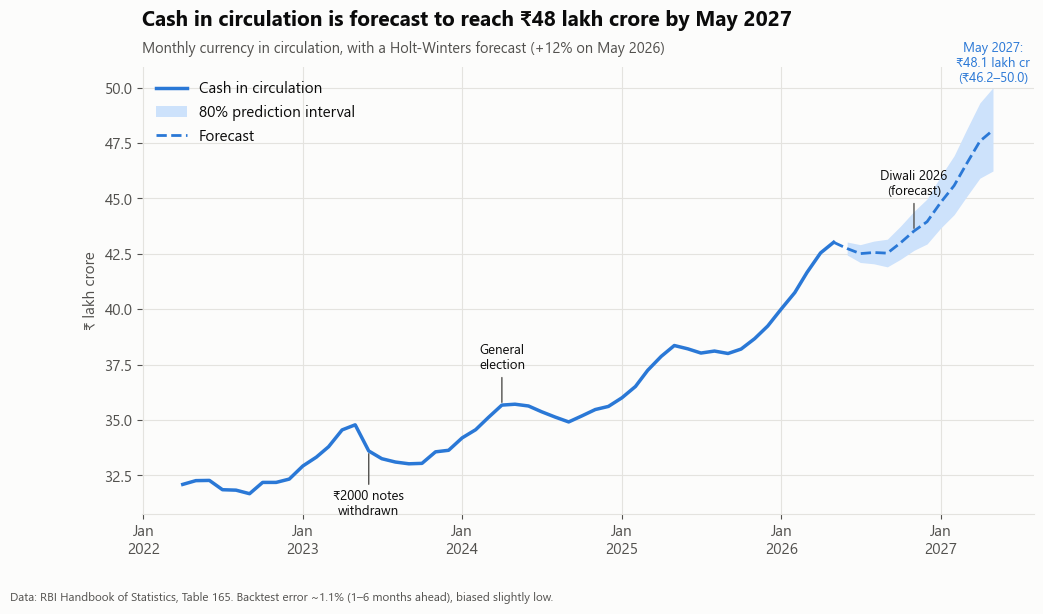

In [11]:
fig, ax = plt.subplots(figsize=(11.5, 5.8))
ax.plot(monthly.month, monthly.cash_lakh_cr, color=BLUE, lw=2.5, label="Cash in circulation")
ax.fill_between(forecast.index, forecast.low_80, forecast.high_80, color=BLUE_LIGHT, lw=0, label="80% prediction interval")
ax.plot([monthly.month.iloc[-1], *forecast.index], [monthly.cash_lakh_cr.iloc[-1], *forecast.forecast],
        color=BLUE, lw=2, ls="--", label="Forecast")
events = {"2023-06-01": "₹2000 notes\nwithdrawn", "2024-04-01": "General\nelection", "2026-11-01": "Diwali 2026\n(forecast)"}
for date, label in events.items():
    d = pd.Timestamp(date)
    v = forecast.forecast.get(d, monthly.set_index("month").cash_lakh_cr.get(d))
    ax.annotate(label, (d, v), xytext=(0, -46 if "withdrawn" in label else 26), textcoords="offset points", ha="center",
                fontsize=9.5, arrowprops=dict(arrowstyle="-", color=INK_2))
may27 = forecast.loc["2027-05-01"]
ax.text(forecast.index[-1], may27.forecast + 2.2, f"May 2027:\n₹{may27.forecast:.1f} lakh cr\n(₹{may27.low_80:.1f}–{may27.high_80:.1f})",
        ha="center", fontsize=9.5, color=BLUE)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_ylabel("₹ lakh crore")
ax.legend(loc="upper left")
titles(ax, f"Cash in circulation is forecast to reach ₹{may27.forecast:.0f} lakh crore by May 2027",
       f"Monthly currency in circulation, with a Holt-Winters forecast ({may27.forecast / monthly.cash_lakh_cr.iloc[-1] - 1:+.0%} on May 2026)")
footnote(fig, "Data: RBI Handbook of Statistics, Table 165. Backtest error ~1.1% (1–6 months ahead), biased slightly low.", y=-0.04)
save(fig, "05_cash_forecast.png")
plt.show()

## 7. A simple projection: will UPI move more money than India's GDP?

In 2025-26 UPI's yearly value reached 90.7% of GDP. If UPI and the economy keep 2025-26's growth rates,
UPI crosses 100% of GDP in 2026-27. These are scenarios, not a model.

In [12]:
last = sql("""
    SELECT u.upi_value_lakh_cr, u.gdp_lakh_cr,
           100 * (u.upi_value_lakh_cr / LAG(u.upi_value_lakh_cr) OVER (ORDER BY fy_start) - 1) AS upi_value_growth_pct,
           c.gdp_growth_pct
    FROM mart_upi_annual u JOIN mart_cash_annual c USING (fy_start)
    ORDER BY fy_start DESC LIMIT 1
""").iloc[0]
scenarios = pd.DataFrame({
    "UPI value growth": [0.15, last.upi_value_growth_pct / 100, 0.25],
    "nominal GDP growth": [0.10, last.gdp_growth_pct / 100, 0.08],
}, index=["Slower UPI", "Same pace as 2025-26", "Faster UPI"])
scenarios["UPI value / GDP, 2026-27"] = (100 * last.upi_value_lakh_cr * (1 + scenarios["UPI value growth"])
                                         / (last.gdp_lakh_cr * (1 + scenarios["nominal GDP growth"]))).round(1)
scenarios

,UPI value growth,nominal GDP growth,"UPI value / GDP, 2026-27"
Slower UPI,0.15,0.10,94.8
Same pace as 2025-26,0.21,0.09,100.4
Faster UPI,0.25,0.08,105.0


## Limitations

- **Stocks against flows.** Cash in circulation is a stock (measured at end-March) and UPI value is a flow
  (summed over the year). Both are shown as a share of GDP, but they measure different things.
  Comparing them shows how each has grown, not that one equals the other.
- **There's no direct measure of cash *use*** (such as ATM withdrawals) in these tables. "UPI replaced small cash
  payments" is inferred from falling ticket sizes and collapsing debit-card volumes, not measured directly.
- **UPI data starts in 2021-22**, the first year in RBI's current handbook table. Earlier figures exist (NPCI)
  but come from a different source, so they're left out.
- **The forecast has only four years of monthly history**, and the backtest shows it tends to under-predict when
  cash growth speeds up.